Health care analysis-

Import libraries

In [79]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

# Model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score

In [80]:
df = pd.read_csv("healthcare_data.csv")

print(df.head())
print(df.info())

   Unnamed: 0  patient_id gender   age  has_hypertension  has_heart_disease  \
0           1       30669      M   3.0                 0                  0   
1           2       30468      M  58.0                 1                  0   
2           3       16523      F   8.0                 0                  0   
3           4       56543      F  70.0                 0                  0   
4           5       46136      M  14.0                 0                  0   

   marital_status employment_type residence  glucose_level  bmi_value  \
0               0           other     Rural          95.12       18.0   
1               1         working     Urban          87.96       39.2   
2               0         working     Urban         110.89       17.6   
3               1         working     Rural          69.04       35.9   
4               0           other     Rural         161.28       19.1   

  smoking_habit  stroke_event age_group  risk_score  high_glucose  \
0       unknown  

In [81]:
print(df.shape)
print(df.columns)
print(df.head())

(9722, 18)
Index(['Unnamed: 0', 'patient_id', 'gender', 'age', 'has_hypertension',
       'has_heart_disease', 'marital_status', 'employment_type', 'residence',
       'glucose_level', 'bmi_value', 'smoking_habit', 'stroke_event',
       'age_group', 'risk_score', 'high_glucose', 'bmi_category',
       'lifestyle_risk'],
      dtype='object')
   Unnamed: 0  patient_id gender   age  has_hypertension  has_heart_disease  \
0           1       30669      M   3.0                 0                  0   
1           2       30468      M  58.0                 1                  0   
2           3       16523      F   8.0                 0                  0   
3           4       56543      F  70.0                 0                  0   
4           5       46136      M  14.0                 0                  0   

   marital_status employment_type residence  glucose_level  bmi_value  \
0               0           other     Rural          95.12       18.0   
1               1         working 

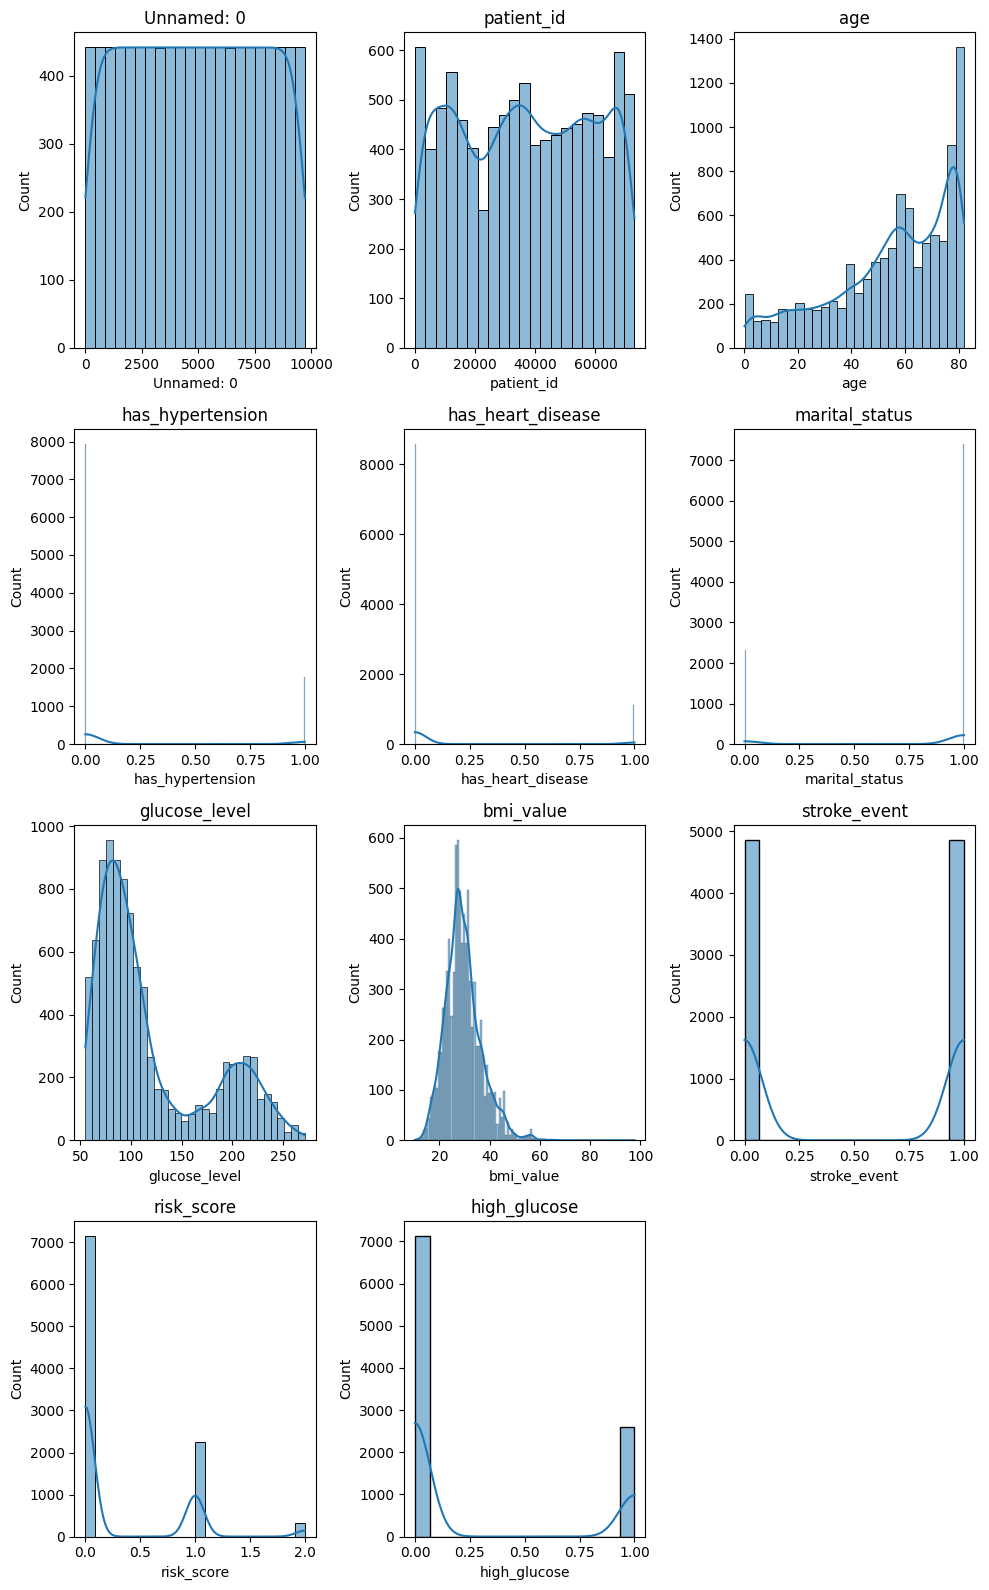

In [84]:



num_cols = df.select_dtypes(include='number').columns

# number of columns
n_cols = len(num_cols)

# create subplot grid (auto layout)
rows = int(np.ceil(n_cols / 3))   # 3 plots per row (you can change this)
cols = 3

plt.figure(figsize=(10, rows * 4))

for i, col in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

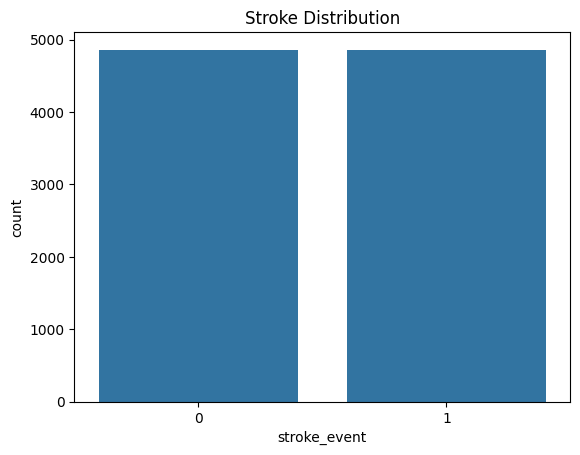

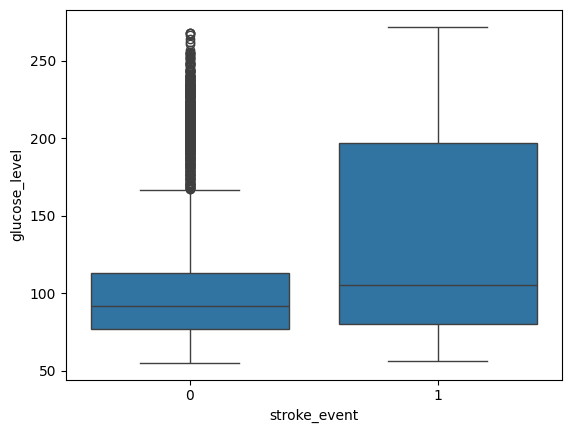

In [35]:
sns.countplot(x="stroke_event", data=df)
plt.title("Stroke Distribution")
plt.show()

sns.boxplot(x="stroke_event", y="glucose_level", data=df)
plt.show()

In [36]:
print(df.isnull().sum())

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

Unnamed: 0             0
patient_id             0
gender                 0
age                    0
has_hypertension       0
has_heart_disease      0
marital_status         0
employment_type        0
residence              0
glucose_level          0
bmi_value            927
smoking_habit          0
stroke_event           0
age_group              0
risk_score             0
high_glucose           0
bmi_category           0
lifestyle_risk         0
dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_38832\1407397289.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [37]:
df = df.drop_duplicates()
print("Duplicates removed")

Duplicates removed


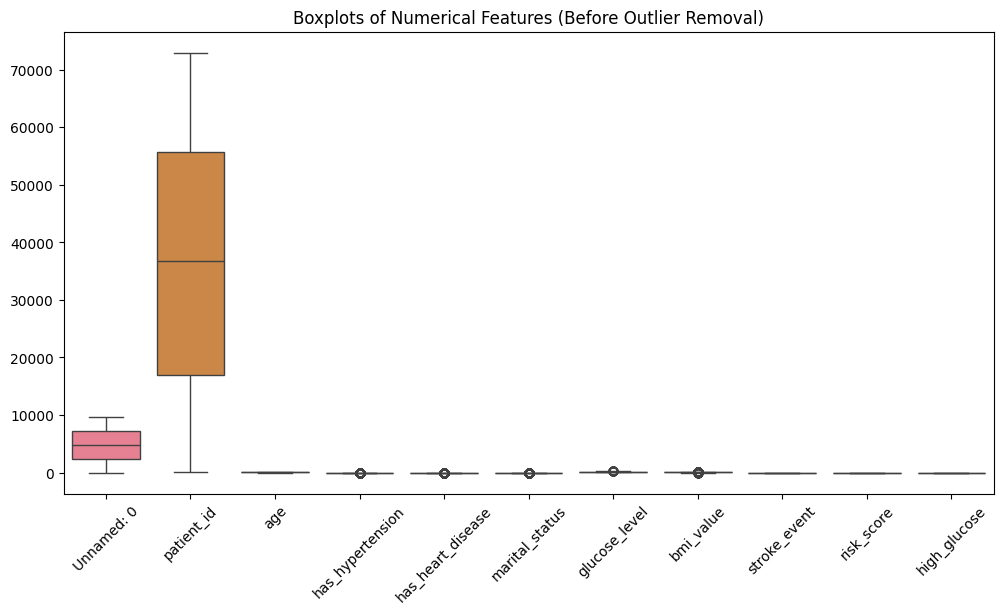

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols])

plt.title("Boxplots of Numerical Features (Before Outlier Removal)")
plt.xticks(rotation=45)
plt.show()

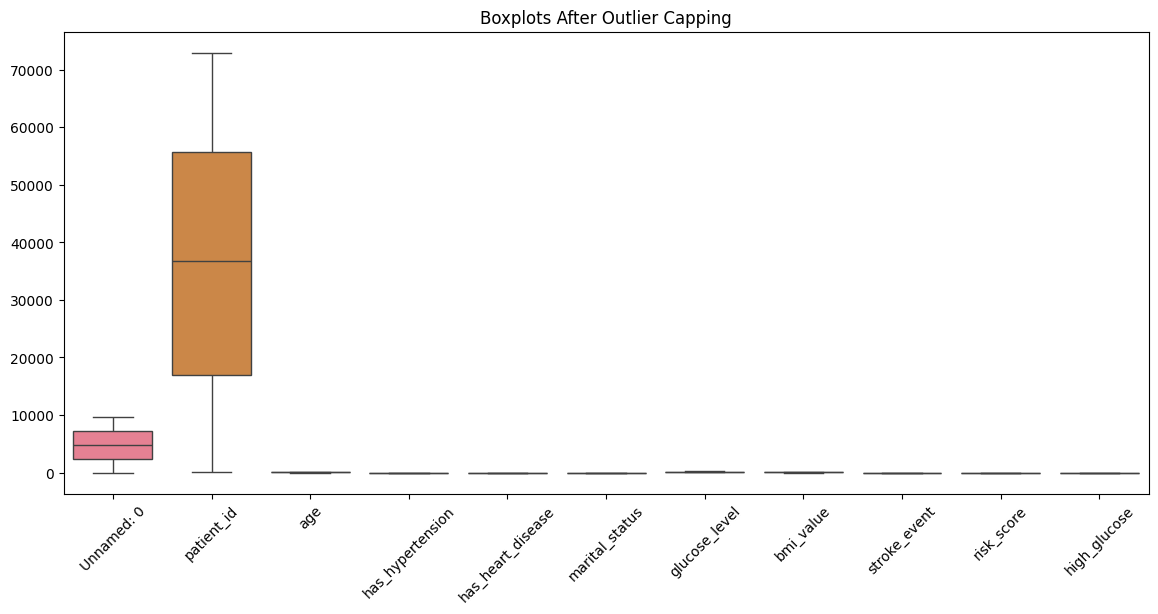

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# --------- OUTLIER HANDLING FUNCTION (CAPPING) ---------
def cap_outliers(df, columns, factor=1.5):
    df_clean = df.copy()
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        
        # Cap values instead of removing
        df_clean[col] = df_clean[col].clip(lower, upper)
    
    return df_clean

# Apply function
df_clean = cap_outliers(df, num_cols)

# --------- PLOT ---------
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean[num_cols])

plt.title("Boxplots After Outlier Capping")
plt.xticks(rotation=45)

plt.show()

In [40]:
print(df_clean.dtypes)

Unnamed: 0             int64
patient_id             int64
gender                object
age                  float64
has_hypertension       int64
has_heart_disease      int64
marital_status         int64
employment_type       object
residence             object
glucose_level        float64
bmi_value            float64
smoking_habit         object
stroke_event           int64
age_group             object
risk_score             int64
high_glucose           int64
bmi_category          object
lifestyle_risk        object
dtype: object


In [41]:
cat_cols = df_clean.select_dtypes(include='object').columns

df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

In [42]:
print(df_encoded.dtypes)

Unnamed: 0                    int64
patient_id                    int64
age                         float64
has_hypertension              int64
has_heart_disease             int64
marital_status                int64
glucose_level               float64
bmi_value                   float64
stroke_event                  int64
risk_score                    int64
high_glucose                  int64
gender_M                       bool
employment_type_other          bool
employment_type_working        bool
residence_Urban                bool
smoking_habit_ex_smoker        bool
smoking_habit_non_smoker       bool
smoking_habit_unknown          bool
age_group_senior               bool
age_group_young                bool
bmi_category_obese             bool
bmi_category_overweight        bool
bmi_category_underweight       bool
lifestyle_risk_low             bool
lifestyle_risk_medium          bool
dtype: object


In [43]:
df_encoded = df_encoded.drop(columns=['patient_id'])

In [44]:

df_clean['age_risk'] = pd.cut(df_clean['age'],
                             bins=[0, 30, 50, 70, 100],
                             labels=['low', 'medium', 'high', 'very_high'])

In [45]:
df_clean['bmi_risk'] = df_clean['bmi_value'].apply(
    lambda x: 0 if x < 18.5 else
              1 if x < 25 else
              2 if x < 30 else
              3
)

In [46]:
df_clean['glucose_risk'] = df_clean['glucose_level'].apply(
    lambda x: 0 if x < 100 else
              1 if x < 125 else
              2
)

In [47]:
df_clean['health_risk_score'] = (
    df_clean['has_hypertension'] +
    df_clean['has_heart_disease'] +
    df_clean['high_glucose']
)

In [48]:
df_clean['lifestyle_combined'] = df_clean['smoking_habit'] + "_" + df_clean['lifestyle_risk']

In [49]:
df_clean['age_hypertension'] = df_clean['age'] * df_clean['has_hypertension']

In [50]:
df_clean['bmi_glucose'] = df_clean['bmi_value'] * df_clean['glucose_level']

In [64]:
X = df_encoded.drop(columns=['stroke_event'])
y = df_encoded['stroke_event']

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
from sklearn.preprocessing import MinMaxScaler

scaler_norm = MinMaxScaler()

X_train_norm = scaler_norm.fit_transform(X_train)
X_test_norm = scaler_norm.transform(X_test)

In [67]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)


In [69]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_std, y_train)

y_pred_lr = lr.predict(X_test_std)

In [70]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [71]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [72]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [73]:
def evaluate_model(name, y_test, y_pred):
    print(f"----- {name} -----")
    
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("Accuracy:", acc)
    print("MSE:", mse)
    print("R2 Score:", r2) 

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\n")   

In [74]:
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)

----- Logistic Regression -----
Accuracy: 0.9943444730077121
MSE: 0.005655526992287918
R2 Score: 0.9773678353516633

Confusion Matrix:
 [[983  10]
 [  1 951]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       993
           1       0.99      1.00      0.99       952

    accuracy                           0.99      1945
   macro avg       0.99      0.99      0.99      1945
weighted avg       0.99      0.99      0.99      1945



----- Decision Tree -----
Accuracy: 1.0
MSE: 0.0
R2 Score: 1.0

Confusion Matrix:
 [[993   0]
 [  0 952]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       993
           1       1.00      1.00      1.00       952

    accuracy                           1.00      1945
   macro avg       1.00      1.00      1.00      1945
weighted avg       1.00      1.00      1.00      1945



----- Random Forest -----
A

In [75]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_dt),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_gb)
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

print(results)

                 Model  Accuracy       MSE        R2
0  Logistic Regression  0.994344  0.005656  0.977368
1        Decision Tree  1.000000  0.000000  1.000000
2        Random Forest  1.000000  0.000000  1.000000
3    Gradient Boosting  1.000000  0.000000  1.000000


In [76]:
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df)

                     Feature  Importance
0                 Unnamed: 0    0.673414
1                        age    0.109461
16          age_group_senior    0.066052
5              glucose_level    0.032946
17           age_group_young    0.027789
6                  bmi_value    0.026318
7                 risk_score    0.018257
8               high_glucose    0.011072
10     employment_type_other    0.008261
18        bmi_category_obese    0.003872
11   employment_type_working    0.003125
9                   gender_M    0.003036
19   bmi_category_overweight    0.002830
14  smoking_habit_non_smoker    0.002511
15     smoking_habit_unknown    0.002483
12           residence_Urban    0.002228
21        lifestyle_risk_low    0.001847
20  bmi_category_underweight    0.001843
13   smoking_habit_ex_smoker    0.001476
22     lifestyle_risk_medium    0.001180
3          has_heart_disease    0.000000
2           has_hypertension    0.000000
4             marital_status    0.000000
